In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)

(569, 30)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history1 = model1.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6319 - loss: 0.6787 - val_accuracy: 0.8791 - val_loss: 0.5006
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8984 - loss: 0.4236 - val_accuracy: 0.9231 - val_loss: 0.3269
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9313 - loss: 0.2853 - val_accuracy: 0.9341 - val_loss: 0.2330
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9478 - loss: 0.2076 - val_accuracy: 0.9560 - val_loss: 0.1822
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9588 - loss: 0.1602 - val_accuracy: 0.9451 - val_loss: 0.1536
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.1318 - val_accuracy: 0.9451 - val_loss: 0.1342
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9753 - loss: 0.1097 - val_accuracy: 0.9670 - val_loss: 0.1219
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9835 - loss: 0.0951 - val_accuracy: 0.9670 - val_loss

In [ ]:
#Early Stopping
# A regularization technique where training is stopped early when validation performance stops improving, to prevent overfitting.

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history2 = model2.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.6566 - loss: 0.6754 - val_accuracy: 0.8132 - val_loss: 0.5114
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8901 - loss: 0.4390 - val_accuracy: 0.9011 - val_loss: 0.3478
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9231 - loss: 0.2931 - val_accuracy: 0.9121 - val_loss: 0.2490
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9451 - loss: 0.2025 - val_accuracy: 0.9451 - val_loss: 0.1910
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9505 - loss: 0.1510 - val_accuracy: 0.9451 - val_loss: 0.1577
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9725 - loss: 0.1183 - val_accuracy: 0.9451 - val_loss: 0.1397
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9753 - loss: 0.0992 - val_accuracy: 0.9451 - val_loss: 0.1270
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9780 - loss: 0.0855 - val_accuracy: 0.

In [ ]:
#Dropout
# A technique where random neurons are turned off during training to prevent over-reliance on specific neurons and reduce overfitting.

model3 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history3 = model3.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.4973 - loss: 0.8377 - val_accuracy: 0.9011 - val_loss: 0.4849
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7363 - loss: 0.5313 - val_accuracy: 0.9670 - val_loss: 0.3718
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8077 - loss: 0.4505 - val_accuracy: 0.9670 - val_loss: 0.2916
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8544 - loss: 0.4218 - val_accuracy: 0.9670 - val_loss: 0.2377
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9011 - loss: 0.3207 - val_accuracy: 0.9560 - val_loss: 0.2025
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9011 - loss: 0.2779 - val_accuracy: 0.9560 - val_loss: 0.1775
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9313 - loss: 0.2556 - val_accuracy: 0.9560 - val_loss: 0.1599
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9396 - loss: 0.2237 - val_accuracy: 0.9560 - v

In [ ]:
print("Baseline Accuracy:", model1.evaluate(X_test, y_test)[1])
print("Early Stopping Accuracy:", model2.evaluate(X_test, y_test)[1])
print("Dropout Accuracy:", model3.evaluate(X_test, y_test)[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9825 - loss: 0.1036 
Baseline Accuracy: 0.9824561476707458
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9649 - loss: 0.0720 
Early Stopping Accuracy: 0.9649122953414917
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9737 - loss: 0.0787 
Dropout Accuracy: 0.9736841917037964


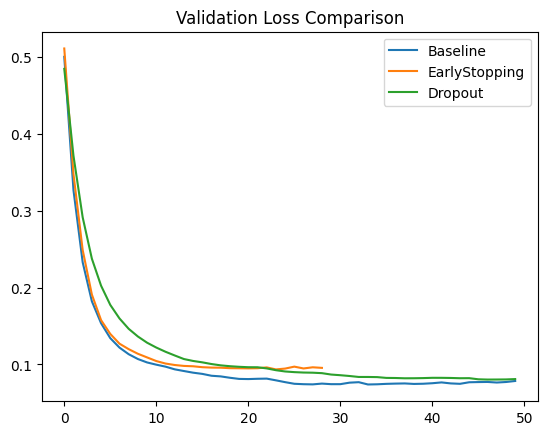

In [ ]:
plt.plot(history1.history['val_loss'], label='Baseline')
plt.plot(history2.history['val_loss'], label='EarlyStopping')
plt.plot(history3.history['val_loss'], label='Dropout')

plt.legend()
plt.title("Validation Loss Comparison")
plt.show()